In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Load:
#   (1) fitted ODMR line-center results from results.csv
#   (2) static ODMR trace from CSV
#
# Units:
#   - ODMR frequency in file: Hz
#   - converted frequency: MHz and GHz
#   - ODMR vertical axis: Voltage-like readout 
#     (same signal family as pulse readout, after local calibration)
# ============================================================

results_df = pd.read_csv("results.csv")

axes_order = ["d1", "d2", "d3", "d4"]

# Tracked lower-transition frequencies from previous static ODMR analysis
# Units: MHz
f_left_centers_mhz = np.array([
    float(results_df.loc[results_df["name"] == "d1_f_left_meas_MHz", "value"].iloc[0]),
    float(results_df.loc[results_df["name"] == "d2_f_left_meas_MHz", "value"].iloc[0]),
    float(results_df.loc[results_df["name"] == "d3_f_left_meas_MHz", "value"].iloc[0]),
    float(results_df.loc[results_df["name"] == "d4_f_left_meas_MHz", "value"].iloc[0]),
], dtype=float)

odmr_csv_path = "/home/vita/projects/NV_sensing/data/ODMR_avg_99-6dBm_0mW.csv"

odmr_df = pd.read_csv(odmr_csv_path, sep=r"\s+")
odmr_df.columns = [c.strip() for c in odmr_df.columns]

freq_col = [c for c in odmr_df.columns if "freq" in c.lower()][0]
sig_col = [c for c in odmr_df.columns if c != freq_col][0]

f_hz_odmr = odmr_df[freq_col].to_numpy(dtype=float)
y_raw_odmr = odmr_df[sig_col].to_numpy(dtype=float)

# Sort by frequency just in case
sort_idx = np.argsort(f_hz_odmr)
f_hz_odmr = f_hz_odmr[sort_idx]
y_raw_odmr = y_raw_odmr[sort_idx]

# Frequency axes in convenient units
f_mhz_odmr = f_hz_odmr / 1e6
f_ghz_odmr = f_hz_odmr / 1e9

print("Tracked lower-transition centers [MHz]:", f_left_centers_mhz)
print("ODMR frequency range [GHz]:", f_ghz_odmr.min(), "to", f_ghz_odmr.max())
print("ODMR raw signal min/max:", np.min(y_raw_odmr), np.max(y_raw_odmr))

Tracked lower-transition centers [MHz]: [2791.20577148 2803.93502334 2855.26217136 2866.88305566]
ODMR frequency range [GHz]: 2.77 to 2.9698
ODMR raw signal min/max: 0.065666 0.078267


# manually check for slope intervals extracted directly from data 


,axis,center_MHz,fit_start_MHz,fit_end_MHz,slope_raw_per_MHz,intercept_raw,n_points
0,d1,2791.205771,2788.0,2788.9,-0.005998,16.798954,5
1,d2,2803.935023,2801.0,2801.7,-0.006857,19.283244,4
2,d3,2855.262171,2852.0,2853.0,-0.002656,7.651833,6
3,d4,2866.883056,2863.9,2864.8,-0.001930,5.603410,5


Final selected slopes [raw ODMR units / MHz]:
d1: -0.005998
d2: -0.006857
d3: -0.002656
d4: -0.001930


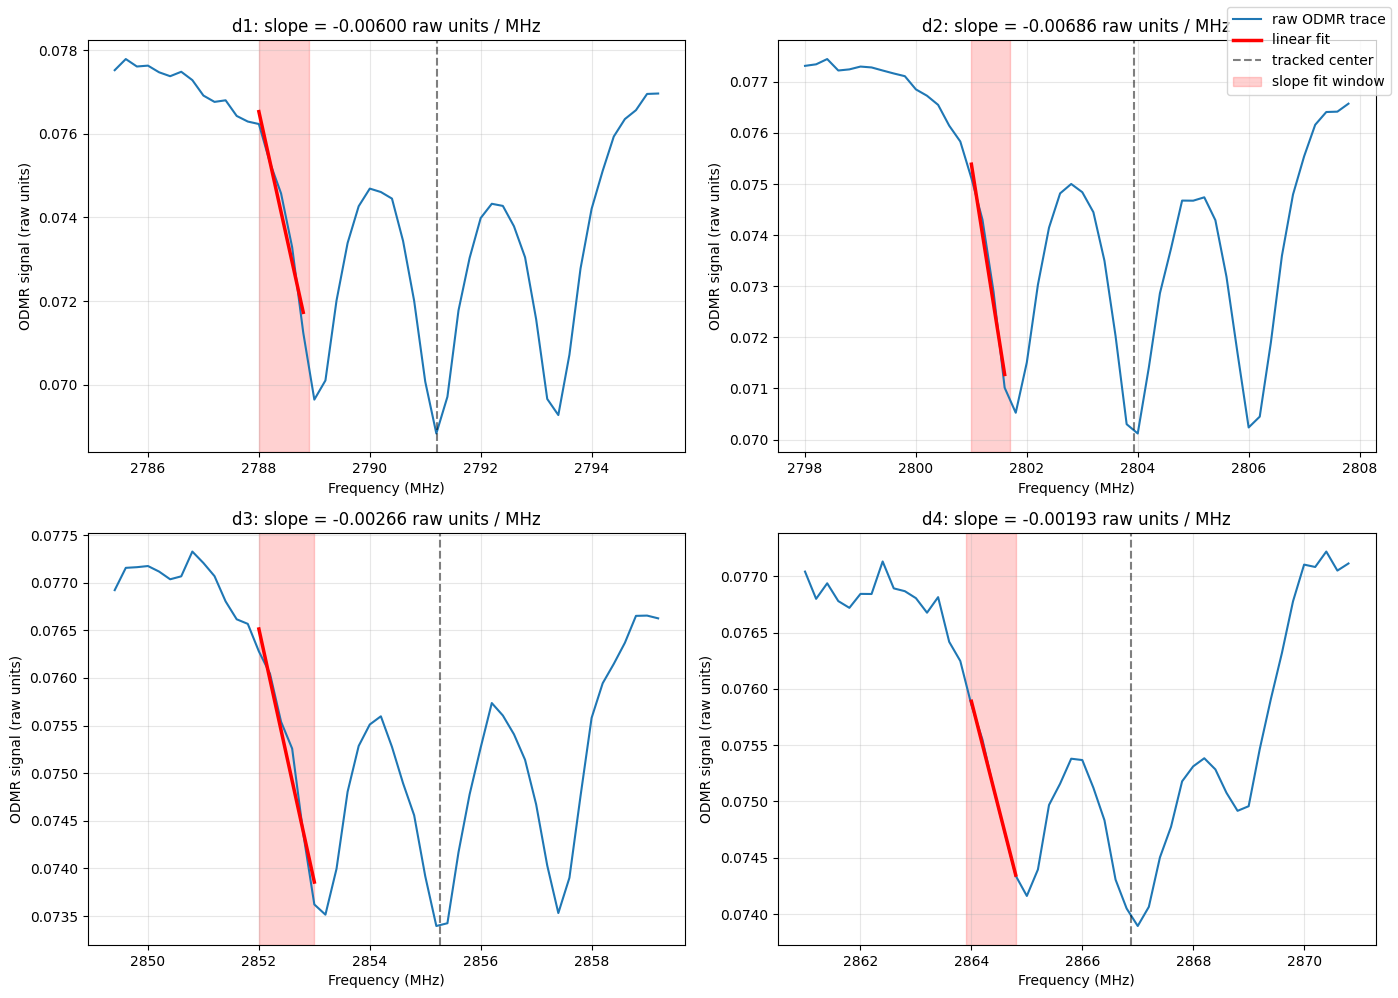

In [3]:

# Manual fit windows for local linear slope extraction.
# Each window should lie on the approximately linear flank of
# the tracked lower-frequency ODMR transition.
# Units:frequency window bounds in MHz

manual_windows = {
    "d1": (2788.0, 2788.9),
    "d2": (2801.0, 2801.7),
    "d3": (2852.0, 2853.0),
    "d4": (2863.9, 2864.8),
}

manual_windows

#Model: V_i(nu) ~ a_i * nu + b_i
# Units:
#   slope_raw_per_MHz : raw ODMR units / MHz
# Validity:
#   This is the small-signal linearization step used to convert
#   a pulse readout change dV into a line-center shift dnu

slope_rows = []

for ax_name in axes_order:
    f_min, f_max = manual_windows[ax_name]
    center = f_left_centers_mhz[axes_order.index(ax_name)]

    mask = (f_mhz_odmr >= f_min) & (f_mhz_odmr <= f_max)

    x_fit = f_mhz_odmr[mask]
    y_fit = y_raw_odmr[mask]

    coeffs = np.polyfit(x_fit, y_fit, deg=1)
    slope_raw_per_mhz = coeffs[0]
    intercept_raw = coeffs[1]

    slope_rows.append({
        "axis": ax_name,
        "center_MHz": center,
        "fit_start_MHz": f_min,
        "fit_end_MHz": f_max,
        "slope_raw_per_MHz": slope_raw_per_mhz,
        "intercept_raw": intercept_raw,
        "n_points": int(np.sum(mask))
    })

slopes_df = pd.DataFrame(slope_rows)
display(slopes_df)

slopes_raw_per_MHz = slopes_df["slope_raw_per_MHz"].to_numpy(dtype=float)

print("Final selected slopes [raw ODMR units / MHz]:")
for ax_name, slope in zip(axes_order, slopes_raw_per_MHz):
    print(f"{ax_name}: {slope:.6f}")


# Plot the static ODMR around each tracked transition and show
# the local linear fit used for signal-to-frequency conversion.=

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

left_span_mhz = 6.0
right_span_mhz = 4.0

for i, ax_name in enumerate(axes_order):
    center = slopes_df.loc[i, "center_MHz"]
    f_min = slopes_df.loc[i, "fit_start_MHz"]
    f_max = slopes_df.loc[i, "fit_end_MHz"]
    slope = slopes_df.loc[i, "slope_raw_per_MHz"]
    intercept = slopes_df.loc[i, "intercept_raw"]

    mask_zoom = (f_mhz_odmr >= center - left_span_mhz) & (f_mhz_odmr <= center + right_span_mhz)
    mask_fit = (f_mhz_odmr >= f_min) & (f_mhz_odmr <= f_max)

    x_fit = f_mhz_odmr[mask_fit]
    y_line = slope * x_fit + intercept

    axes[i].plot(f_mhz_odmr[mask_zoom], y_raw_odmr[mask_zoom], lw=1.5, label="raw ODMR trace")
    axes[i].plot(x_fit, y_line, color="red", lw=2.5, label="linear fit")
    axes[i].axvline(center, color="k", ls="--", alpha=0.5, label="tracked center" if i == 0 else None)
    axes[i].axvspan(f_min, f_max, color="red", alpha=0.18, label="slope fit window" if i == 0 else None)

    axes[i].set_title(f"{ax_name}: slope = {slope:.5f} raw units / MHz")
    axes[i].set_xlabel("Frequency (MHz)")
    axes[i].set_ylabel("ODMR signal (raw units)")
    axes[i].grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
plt.tight_layout()
plt.show()

# reconstruction- determine positive, negative, off times 

In [4]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Paths
# -----------------------------
odmr_csv_path = "/home/vita/projects/NV_sensing/data/ODMR_avg_99-6dBm_0mW.csv"
pulse_folder = "Avg_npy_pulse"

# -----------------------------
# Load ODMR CSV
# -----------------------------
odmr_df = pd.read_csv(odmr_csv_path, sep=r"\s+")
odmr_df.columns = [c.strip() for c in odmr_df.columns]

freq_col = [c for c in odmr_df.columns if "freq" in c.lower()][0]
sig_col = [c for c in odmr_df.columns if c != freq_col][0]

f_hz = odmr_df[freq_col].to_numpy(dtype=float)
y_odmr = odmr_df[sig_col].to_numpy(dtype=float)

sort_idx = np.argsort(f_hz)
f_hz = f_hz[sort_idx]
y_odmr = y_odmr[sort_idx]

f_mhz = f_hz / 1e6
f_ghz = f_hz / 1e9

# -----------------------------
# Load pulse NPY files
# -----------------------------
npy_files = sorted(glob.glob(os.path.join(pulse_folder, "Pulse_avg_d*.npy")))
print("Found pulse files:")
for f in npy_files:
    print("  ", f)

all_data = [np.load(f) for f in npy_files]

# Basic checks
print("\nODMR columns:", odmr_df.columns.tolist())
print("ODMR frequency range:")
print("  Hz :", np.nanmin(f_hz), "to", np.nanmax(f_hz))
print("  MHz:", np.nanmin(f_mhz), "to", np.nanmax(f_mhz))
print("  GHz:", np.nanmin(f_ghz), "to", np.nanmax(f_ghz))
print("ODMR signal range:", np.nanmin(y_odmr), "to", np.nanmax(y_odmr))
print("ODMR signal mean/std:", np.nanmean(y_odmr), np.nanstd(y_odmr))

print("\nPulse file diagnostics:")
for path, arr in zip(npy_files, all_data):
    time = arr[:, 0]
    signal = arr[:, 1:]
    dt = np.diff(time)

    print("\n", os.path.basename(path))
    print("  array shape:", arr.shape)
    print("  time range [s]:", np.nanmin(time), "to", np.nanmax(time))
    print("  dt median [s]:", np.nanmedian(dt))
    print("  approx frame rate [Hz]:", 1 / np.nanmedian(dt))
    print("  number of pixels:", signal.shape[1])
    print("  signal min/max:", np.nanmin(signal), "to", np.nanmax(signal))
    print("  signal mean/std:", np.nanmean(signal), np.nanstd(signal))
    print("  first row, first 8 values:", arr[0, :8])

Found pulse files:
   Avg_npy_pulse/Pulse_avg_d1.npy
   Avg_npy_pulse/Pulse_avg_d2.npy
   Avg_npy_pulse/Pulse_avg_d3.npy
   Avg_npy_pulse/Pulse_avg_d4.npy

ODMR columns: ['Frequency', 'Pixel(95-95)']
ODMR frequency range:
  Hz : 2770000000.0 to 2969800000.0
  MHz: 2770.0 to 2969.8
  GHz: 2.77 to 2.9698
ODMR signal range: 0.065666 to 0.078267
ODMR signal mean/std: 0.07640028 0.0021756956950823797

Pulse file diagnostics:

 Pulse_avg_d1.npy
  array shape: (457, 962)
  time range [s]: 0.0 to 0.1761984
  dt median [s]: 0.0003864000000000003
  approx frame rate [Hz]: 2587.991718426499
  number of pixels: 961
  signal min/max: -27890.190545706435 to 18260.328441008965
  signal mean/std: -47.31283041757473 1859.6597355101255
  first row, first 8 values: [  0.          79.45753416  97.92601726 106.25238722 111.62759992
 169.3866201  227.40152982 215.0284276 ]

 Pulse_avg_d2.npy
  array shape: (457, 962)
  time range [s]: 0.0 to 0.1761984
  dt median [s]: 0.0003864000000000003
  approx frame ra

ODMR vertical axis:
  min/max : 0.065666 0.078267
  mean/std: 0.07640028 0.0021756956950823797
  peak-to-peak: 0.012601000000000001


,axis,pulse_raw_min,pulse_raw_max,pulse_raw_mean,pulse_raw_std,Voff_mean,Voff_std,dV_pos_p50_abs,dV_pos_p95_abs,dV_pos_max_abs,dV_neg_p50_abs,dV_neg_p95_abs,dV_neg_max_abs
0,d1,-27890.190546,18260.328441,-47.312830,1859.659736,0.451861,79.292879,3197.303796,22862.533561,27826.952527,2706.809814,12951.504520,18021.282149
1,d2,-5628.316335,2454.757635,-22.105395,464.543033,14.767126,46.659259,1389.373735,4537.348451,5612.684706,752.026045,1947.965896,2419.775433
2,d3,-6065.087766,5403.045040,-0.415110,595.252241,-30.727268,106.895848,1999.872958,4629.085658,6024.958306,1920.733547,4251.278999,5267.995544
3,d4,-6877.147034,7990.849407,44.637488,749.850861,-185.176485,276.470286,1217.456300,4706.342761,7592.565674,1557.544474,4616.295148,5727.462268


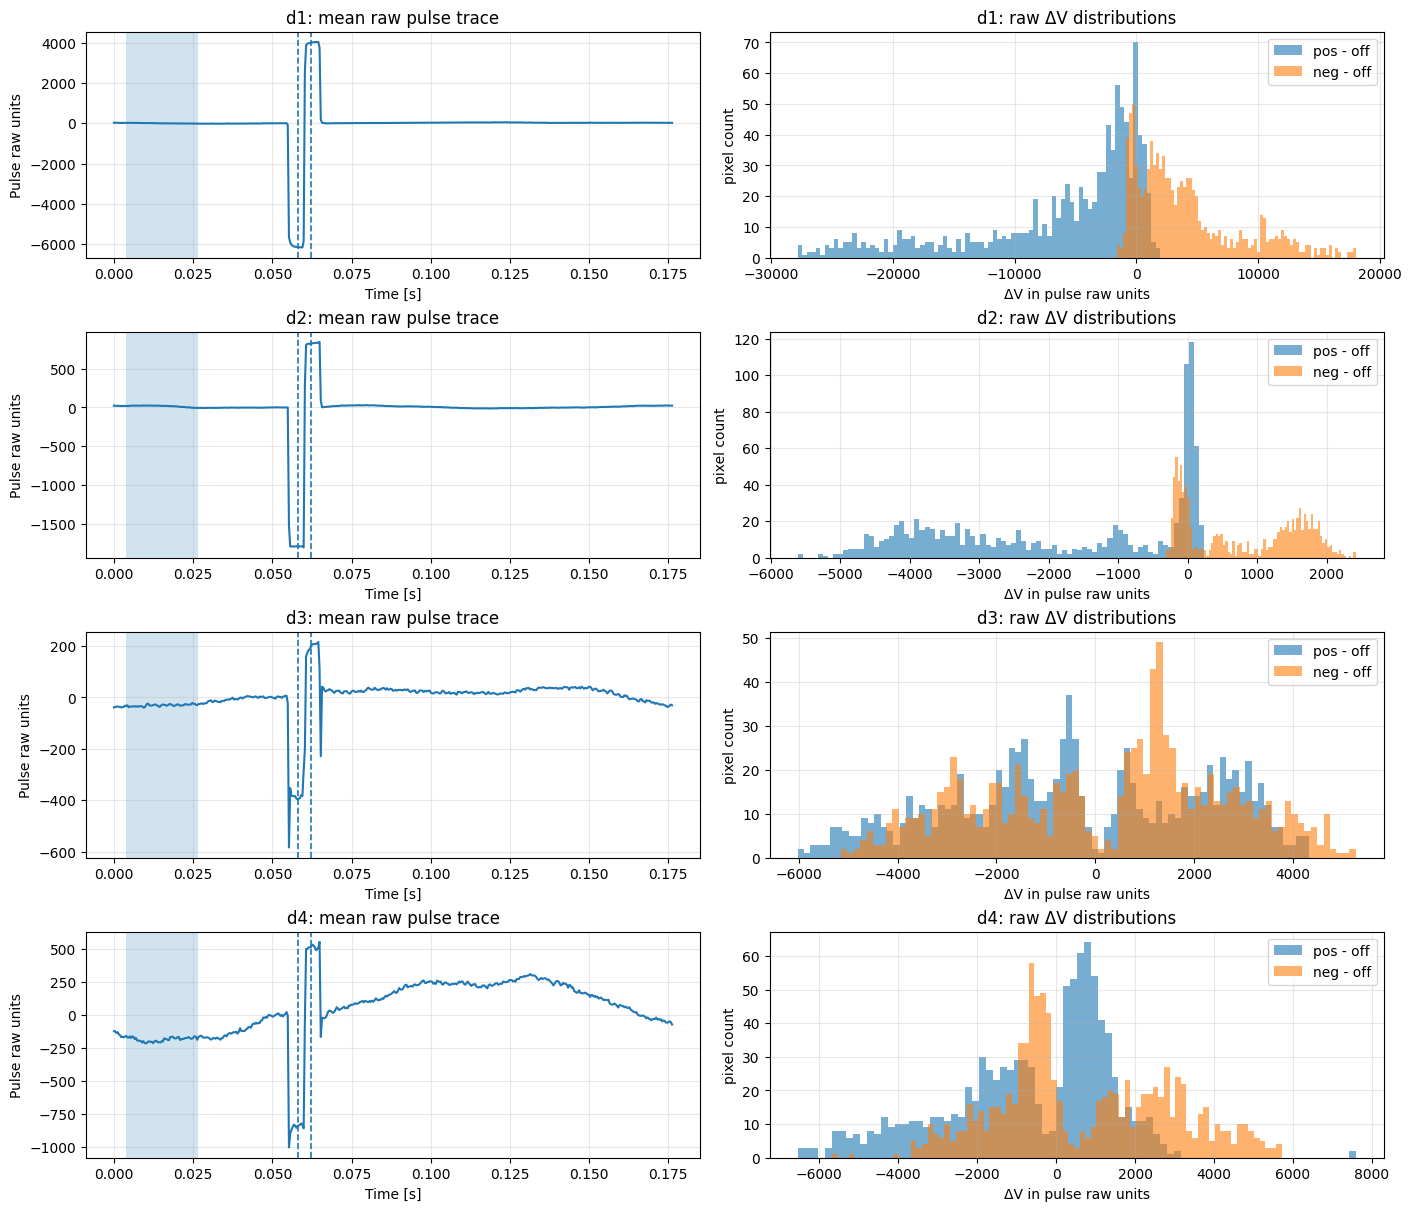


Diagnostic question:
If pulse raw units and ODMR raw units are truly the same, then
typical |dV_pos| should be meaningfully comparable to the ODMR signal scale.
If pulse raw values are orders of magnitude larger/smaller, you need a measured transfer factor.


In [5]:
# ------------------------------------------------------------
# Compare ODMR vertical units and pulse vertical units directly.
# No alpha. No magnetic conversion. Just raw scale inspection.
# ------------------------------------------------------------

axes_order = ["d1", "d2", "d3", "d4"]

# Rebuild stack
time = all_data[0][:, 0]
voltage_stack = np.stack([arr[:, 1:] for arr in all_data], axis=0)
# shape: (4, n_timepoints, n_pixels)

# Choose diagnostic intervals/frames
off_indices = np.arange(10, 70)
pos_idx = 150
neg_idx = 161

V_off = np.mean(voltage_stack[:, off_indices, :], axis=1)
V_pos = voltage_stack[:, pos_idx, :]
V_neg = voltage_stack[:, neg_idx, :]

dV_pos = V_pos - V_off
dV_neg = V_neg - V_off

# Summarize raw pulse values and raw pulse differences
rows = []
for i, name in enumerate(axes_order):
    raw_all = voltage_stack[i].ravel()
    off_all = V_off[i].ravel()
    dpos = dV_pos[i].ravel()
    dneg = dV_neg[i].ravel()

    rows.append({
        "axis": name,
        "pulse_raw_min": np.nanmin(raw_all),
        "pulse_raw_max": np.nanmax(raw_all),
        "pulse_raw_mean": np.nanmean(raw_all),
        "pulse_raw_std": np.nanstd(raw_all),
        "Voff_mean": np.nanmean(off_all),
        "Voff_std": np.nanstd(off_all),
        "dV_pos_p50_abs": np.nanpercentile(np.abs(dpos), 50),
        "dV_pos_p95_abs": np.nanpercentile(np.abs(dpos), 95),
        "dV_pos_max_abs": np.nanmax(np.abs(dpos)),
        "dV_neg_p50_abs": np.nanpercentile(np.abs(dneg), 50),
        "dV_neg_p95_abs": np.nanpercentile(np.abs(dneg), 95),
        "dV_neg_max_abs": np.nanmax(np.abs(dneg)),
    })

scale_df = pd.DataFrame(rows)

print("ODMR vertical axis:")
print("  min/max :", np.nanmin(y_odmr), np.nanmax(y_odmr))
print("  mean/std:", np.nanmean(y_odmr), np.nanstd(y_odmr))
print("  peak-to-peak:", np.nanmax(y_odmr) - np.nanmin(y_odmr))

display(scale_df)

# Plot mean traces and histograms of raw pulse differences
fig, axes = plt.subplots(4, 2, figsize=(14, 12), constrained_layout=True)

for i, name in enumerate(axes_order):
    mean_trace = np.nanmean(voltage_stack[i], axis=1)

    axes[i, 0].plot(time, mean_trace, lw=1.5)
    axes[i, 0].axvspan(time[off_indices[0]], time[off_indices[-1]], alpha=0.2)
    axes[i, 0].axvline(time[pos_idx], ls="--", lw=1.2)
    axes[i, 0].axvline(time[neg_idx], ls="--", lw=1.2)
    axes[i, 0].set_title(f"{name}: mean raw pulse trace")
    axes[i, 0].set_xlabel("Time [s]")
    axes[i, 0].set_ylabel("Pulse raw units")
    axes[i, 0].grid(True, alpha=0.3)

    axes[i, 1].hist(dV_pos[i].ravel(), bins=80, alpha=0.6, label="pos - off")
    axes[i, 1].hist(dV_neg[i].ravel(), bins=80, alpha=0.6, label="neg - off")
    axes[i, 1].set_title(f"{name}: raw ΔV distributions")
    axes[i, 1].set_xlabel("ΔV in pulse raw units")
    axes[i, 1].set_ylabel("pixel count")
    axes[i, 1].legend()
    axes[i, 1].grid(True, alpha=0.3)

plt.show()

# Optional direct diagnostic:
print("\nDiagnostic question:")
print("If pulse raw units and ODMR raw units are truly the same, then")
print("typical |dV_pos| should be meaningfully comparable to the ODMR signal scale.")
print("If pulse raw values are orders of magnitude larger/smaller, you need a measured transfer factor.")

In [6]:

# Cell 5
# Load pulse data.
#
# Data structure of each .npy file:
#   first column  = time (s)
#   remaining cols = pixel readout traces (raw voltage)

import os
import glob

folder = "Avg_npy_pulse"
npy_files = sorted(glob.glob(os.path.join(folder, "Pulse_avg_d*.npy")))

print("Found files:", npy_files)

assert len(npy_files) == 4, "Expected exactly 4 pulse files (d1-d4)."

all_data = [np.load(f) for f in npy_files]

time = all_data[0][:, 0]
voltage_stack = np.stack([arr[:, 1:] for arr in all_data], axis=0)

n_timepoints = voltage_stack.shape[1]
n_pixels = voltage_stack.shape[2]

Found files: ['Avg_npy_pulse/Pulse_avg_d1.npy', 'Avg_npy_pulse/Pulse_avg_d2.npy', 'Avg_npy_pulse/Pulse_avg_d3.npy', 'Avg_npy_pulse/Pulse_avg_d4.npy']


In [7]:
grid_size = int(np.sqrt(n_pixels))
grid = np.zeros((grid_size, grid_size), dtype=int)

for idx in range(n_pixels):
    col = idx // grid_size
    row = idx % grid_size

    if col % 2 == 0:
        grid[grid_size - 1 - row, grid_size - 1 - col] = idx
    else:
        grid[row, grid_size - 1 - col] = idx

print("grid shape:", grid.shape)

grid shape: (31, 31)


In [8]:
off_indices = np.arange(10, 70)   # OFF interval used for averaging

pos_idx = 150                     # one selected positive-phase frame
neg_idx = 161                     # one selected negative-phase frame

# OFF frame: average over OFF interval
V_off = np.mean(voltage_stack[:, off_indices, :], axis=1)   # shape (4, n_pixels)

V_pos = voltage_stack[:, pos_idx, :]
V_neg = voltage_stack[:, neg_idx, :]

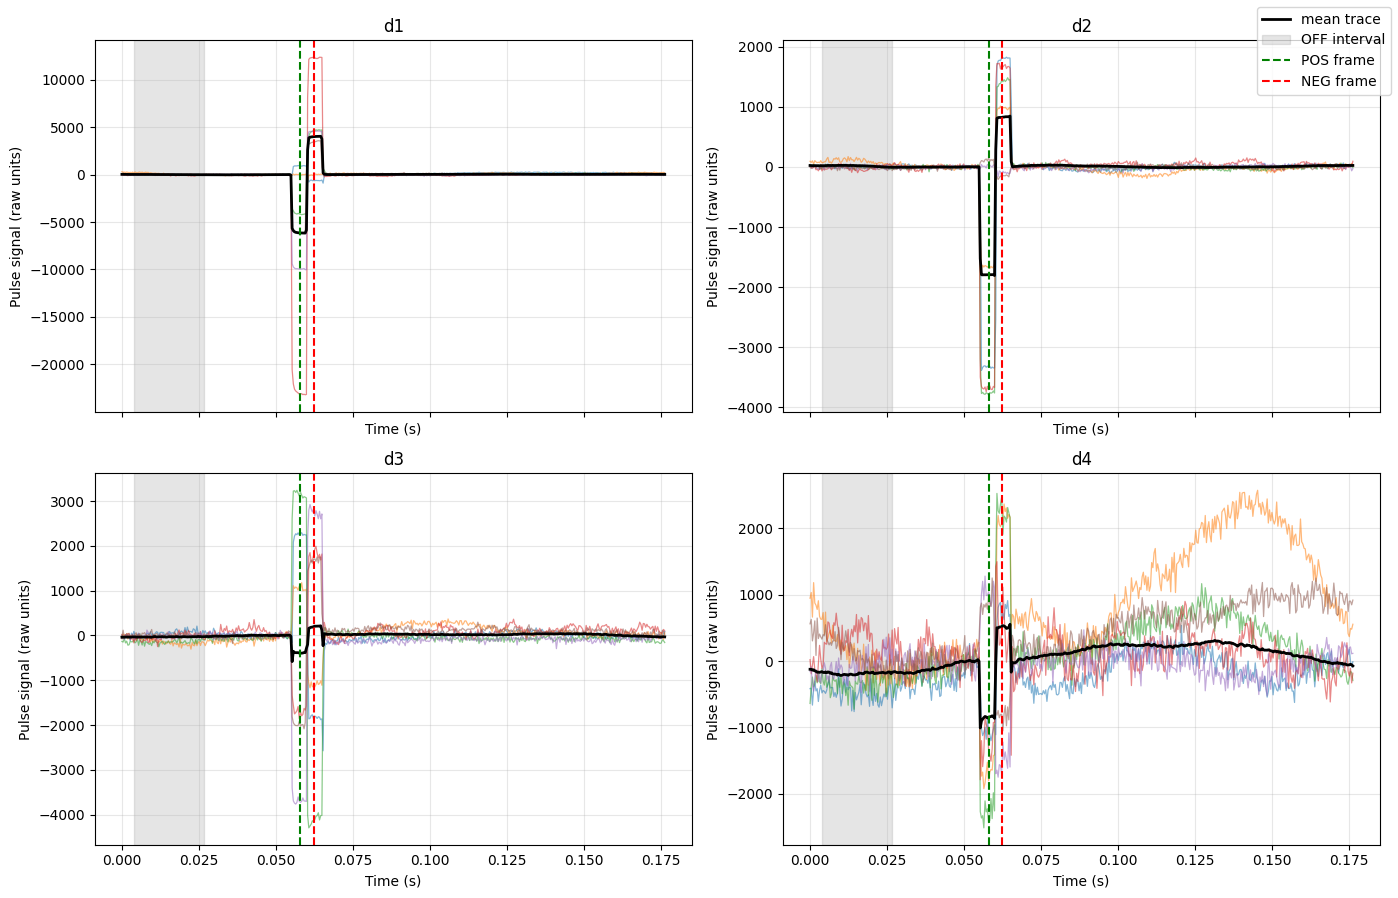

In [9]:
pixel_list = [0, 100, 250, 450, 700, 900]

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
axes = axes.ravel()

for i, ax_name in enumerate(axes_order):
    ax = axes[i]

    for pix in pixel_list:
        ax.plot(time, voltage_stack[i, :, pix], lw=0.9, alpha=0.55)

    mean_trace = np.mean(voltage_stack[i], axis=1)
    ax.plot(time, mean_trace, color="black", lw=2.0, label="mean trace")

    ax.axvspan(
        time[off_indices[0]],
        time[off_indices[-1]],
        color="gray",
        alpha=0.2,
        label="OFF interval" if i == 0 else None
    )
    ax.axvline(time[pos_idx], color="green", ls="--", lw=1.5, label="POS frame" if i == 0 else None)
    ax.axvline(time[neg_idx], color="red", ls="--", lw=1.5, label="NEG frame" if i == 0 else None)

    ax.set_title(ax_name)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Pulse signal (raw units)")
    ax.grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
plt.tight_layout()
plt.show()

In [10]:
# Build raw spatial maps
# and raw difference maps: dV = V_phase - V_off
# Units:V_off, V_pos, V_neg, dV_pos, dV_neg are all in raw units

extent_um = [-100, 100, -100, 100]

Voff_maps = V_off[:, grid]
Vpos_maps = V_pos[:, grid]
Vneg_maps = V_neg[:, grid]

dV_pos = V_pos - V_off
dV_neg = V_neg - V_off

dV_pos_maps = dV_pos[:, grid]
dV_neg_maps = dV_neg[:, grid]

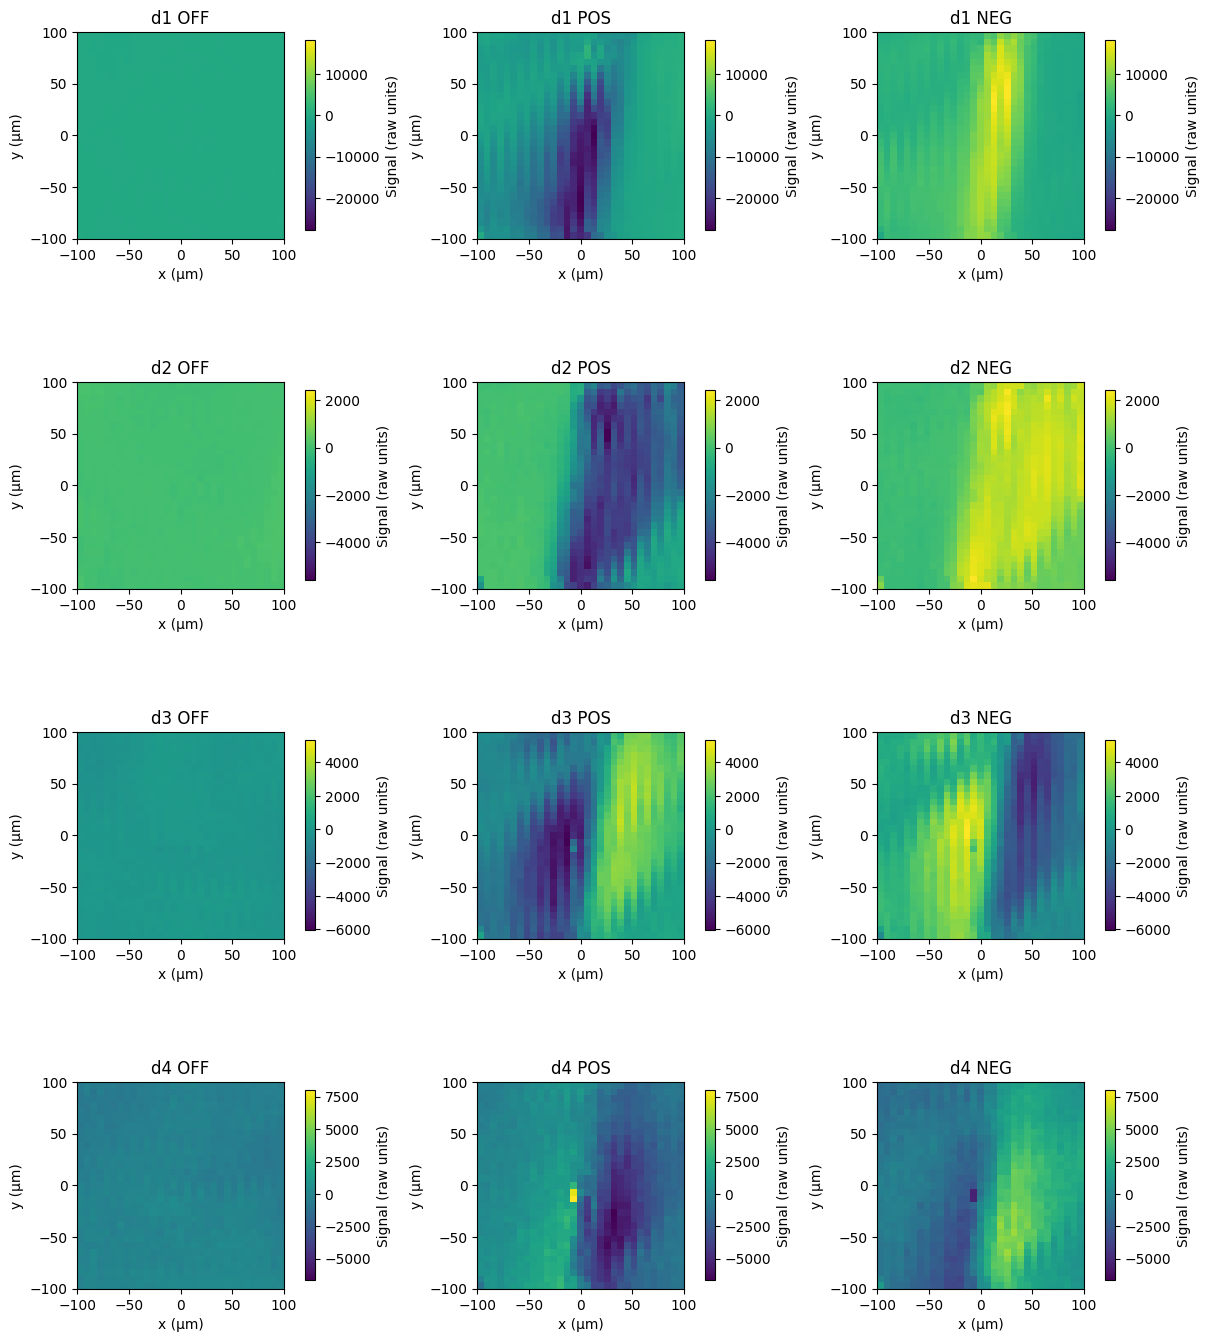

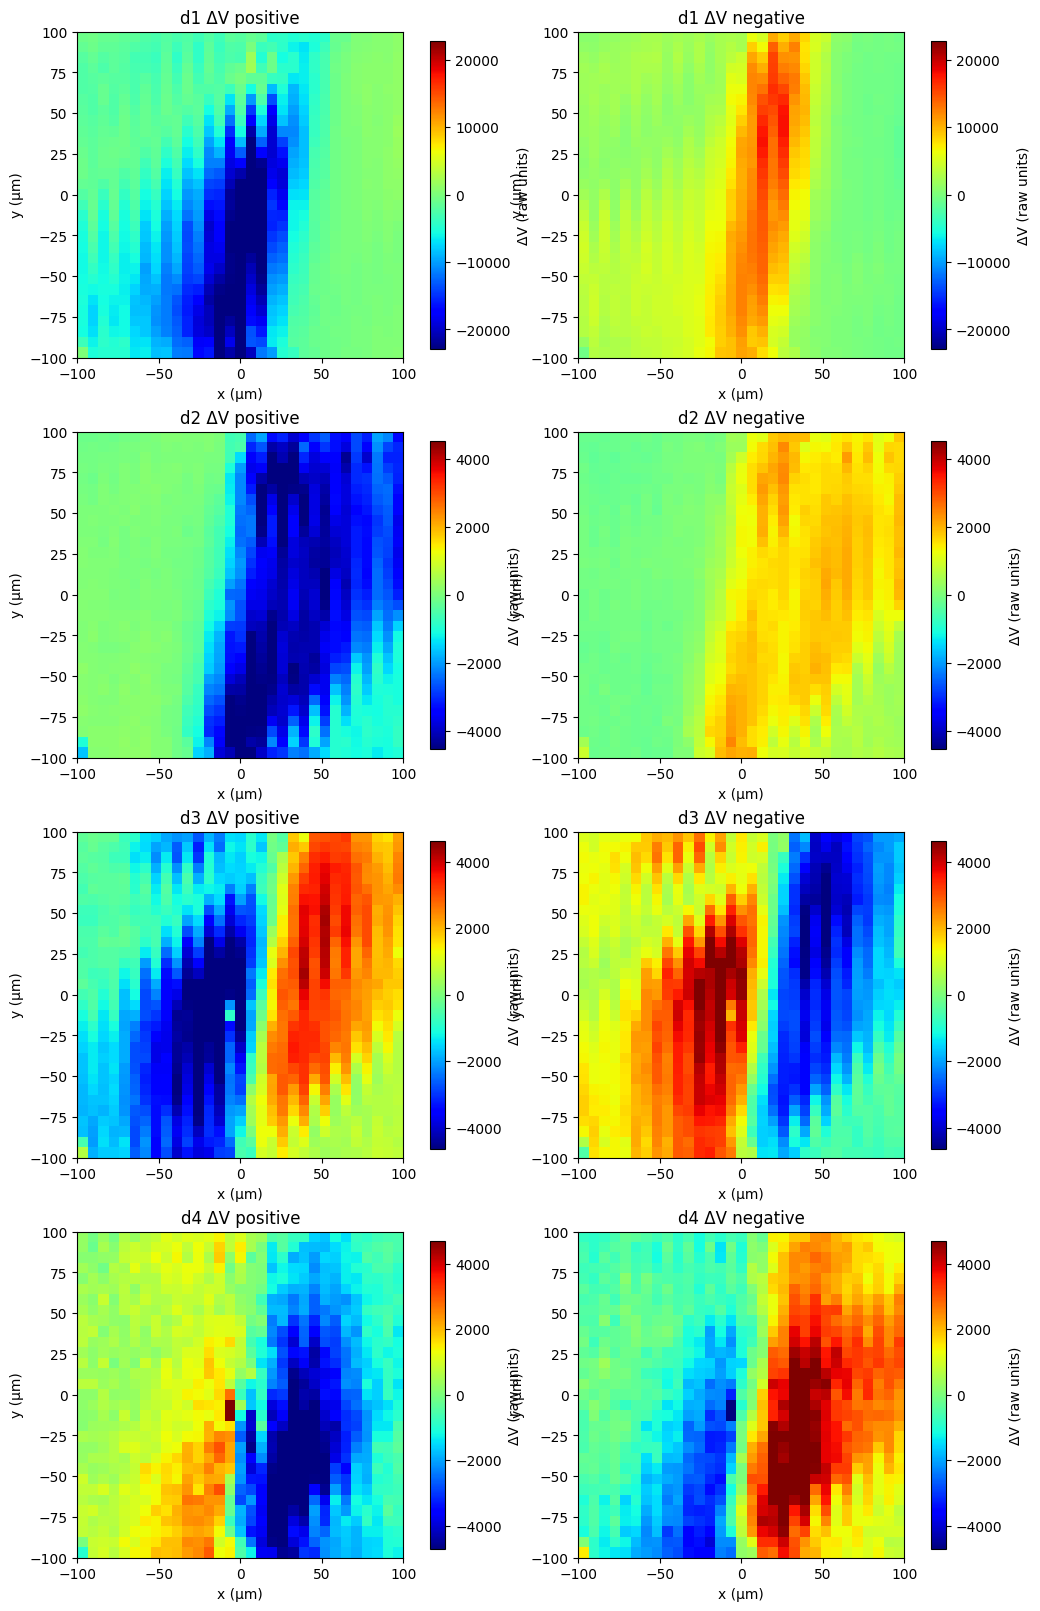

In [11]:
fig, axes = plt.subplots(4, 3, figsize=(12, 14), constrained_layout=True)

for i, ax_name in enumerate(axes_order):
    arrs = [Voff_maps[i], Vpos_maps[i], Vneg_maps[i]]
    titles = [f"{ax_name} OFF", f"{ax_name} POS", f"{ax_name} NEG"]

    vmin = min(np.nanmin(a) for a in arrs)
    vmax = max(np.nanmax(a) for a in arrs)

    for j in range(3):
        im = axes[i, j].imshow(
            arrs[j],
            extent=extent_um,
            origin="lower",
            aspect="equal",
            cmap="viridis",
            vmin=vmin,
            vmax=vmax
        )
        axes[i, j].set_title(titles[j])
        axes[i, j].set_xlabel("x (µm)")
        axes[i, j].set_ylabel("y (µm)")
        cbar = plt.colorbar(im, ax=axes[i, j], fraction=0.046, pad=0.04)
        cbar.set_label("Signal (raw units)")

plt.show()

fig, axes = plt.subplots(4, 2, figsize=(10, 16), constrained_layout=True)

for i, ax_name in enumerate(axes_order):
    lim = max(
        np.nanpercentile(np.abs(dV_pos_maps[i]), 95),
        np.nanpercentile(np.abs(dV_neg_maps[i]), 95)
    )
    if lim == 0:
        lim = 1.0

    im1 = axes[i, 0].imshow(
        dV_pos_maps[i],
        extent=extent_um,
        origin="lower",
        aspect="equal",
        cmap="jet",
        vmin=-lim,
        vmax=lim
    )
    axes[i, 0].set_title(f"{ax_name} ΔV positive")
    axes[i, 0].set_xlabel("x (µm)")
    axes[i, 0].set_ylabel("y (µm)")
    cbar1 = plt.colorbar(im1, ax=axes[i, 0], fraction=0.046, pad=0.04)
    cbar1.set_label("ΔV (raw units)")

    im2 = axes[i, 1].imshow(
        dV_neg_maps[i],
        extent=extent_um,
        origin="lower",
        aspect="equal",
        cmap="jet",
        vmin=-lim,
        vmax=lim
    )
    axes[i, 1].set_title(f"{ax_name} ΔV negative")
    axes[i, 1].set_xlabel("x (µm)")
    axes[i, 1].set_ylabel("y (µm)")
    cbar2 = plt.colorbar(im2, ax=axes[i, 1], fraction=0.046, pad=0.04)
    cbar2.set_label("ΔV (raw units)")

plt.show()

In [12]:
# Pulse-to-ODMR amplitude calibration factors
# These map saved pulse-array units into the saved ODMR-voltage units
# used to fit the local ODMR slopes dV/dnu.
alpha = np.array([5e-6, 1e-5, 5e-6, 5e-6], dtype=float)

# Convert raw pulse differences into ODMR-equivalent voltage units
dV_pos_odmr_units = alpha[:, None] * dV_pos
dV_neg_odmr_units = alpha[:, None] * dV_neg

# Signed local ODMR slopes [ODMR voltage units / MHz]
slopes_raw_per_MHz = slopes_df["slope_raw_per_MHz"].to_numpy(dtype=float)

# Frequency shifts [MHz]
deltaNu_pos = dV_pos_odmr_units / slopes_raw_per_MHz[:, None]
deltaNu_neg = dV_neg_odmr_units / slopes_raw_per_MHz[:, None]

In [13]:
# Load the calibrated pseudoinverse response matrix A+.
#   A_plus : mT / MHz

A_results_df = pd.read_csv("A_results.csv")

A_plus = np.zeros((3, 4), dtype=float)

for i, comp in enumerate(["Bx", "By", "Bz"]):
    for j, ax_name in enumerate(axes_order):
        A_plus[i, j] = float(
            A_results_df.loc[
                (A_results_df["group"] == "A_plus") &
                (A_results_df["row"] == comp) &
                (A_results_df["col"] == ax_name),
                "value"
            ].iloc[0]
        )

print("A_plus [mT/MHz]:\n", A_plus)

A_plus [mT/MHz]:
 [[-0.00196802 -0.00292597 -0.02287232 -0.02238438]
 [-0.02295424 -0.02253042 -0.00040755 -0.00032227]
 [-0.01562025  0.01578408 -0.01386735  0.01475487]]


In [14]:
#reconstruct B in carteasian frame
# Units:
#   deltaNu : MHz
#   A_plus  : mT / MHz
#   B       : mT
#   B_*_nT  : nT


B_pos_mT = A_plus @ deltaNu_pos
B_neg_mT = A_plus @ deltaNu_neg

B_pos_nT = 1e6 * B_pos_mT
B_neg_nT = 1e6 * B_neg_mT

Bx_pos_map = B_pos_nT[0][grid]
By_pos_map = B_pos_nT[1][grid]
Bz_pos_map = B_pos_nT[2][grid]

Bx_neg_map = B_neg_nT[0][grid]
By_neg_map = B_neg_nT[1][grid]
Bz_neg_map = B_neg_nT[2][grid]

Bx_lim = max(np.nanpercentile(np.abs(Bx_pos_map), 95),
             np.nanpercentile(np.abs(Bx_neg_map), 95))
By_lim = max(np.nanpercentile(np.abs(By_pos_map), 95),
             np.nanpercentile(np.abs(By_neg_map), 95))
Bz_lim = max(np.nanpercentile(np.abs(Bz_pos_map), 95),
             np.nanpercentile(np.abs(Bz_neg_map), 95))

In [15]:
for name, arr in zip(
    ["Bx_pos", "By_pos", "Bz_pos", "Bx_neg", "By_neg", "Bz_neg"],
    [B_pos_mT[0], B_pos_mT[1], B_pos_mT[2], B_neg_mT[0], B_neg_mT[1], B_neg_mT[2]]
):
    vals = np.abs(arr).ravel()
    print(
        name,
        "| p50 [mT] =", np.nanpercentile(vals, 50),
        "| p95 [mT] =", np.nanpercentile(vals, 95),
        "| max [mT] =", np.nanmax(vals)
    )

Bx_pos | p50 [mT] = 0.05594576904565216 | p95 [mT] = 0.23009875985560718 | max [mT] = 0.39910859092769313
By_pos | p50 [mT] = 0.11520971524180912 | p95 [mT] = 0.5543495442632362 | max [mT] = 0.6819554786792331
Bz_pos | p50 [mT] = 0.16392505755939424 | p95 [mT] = 0.37788921457892743 | max [mT] = 0.5803399639625502
Bx_neg | p50 [mT] = 0.05355712826723589 | p95 [mT] = 0.1665611794792615 | max [mT] = 0.2699081590885628
By_neg | p50 [mT] = 0.06409924711329228 | p95 [mT] = 0.3050200309583141 | max [mT] = 0.4158676153274853
Bz_neg | p50 [mT] = 0.14672443050131018 | p95 [mT] = 0.27573263008101667 | max [mT] = 0.3563774809751201


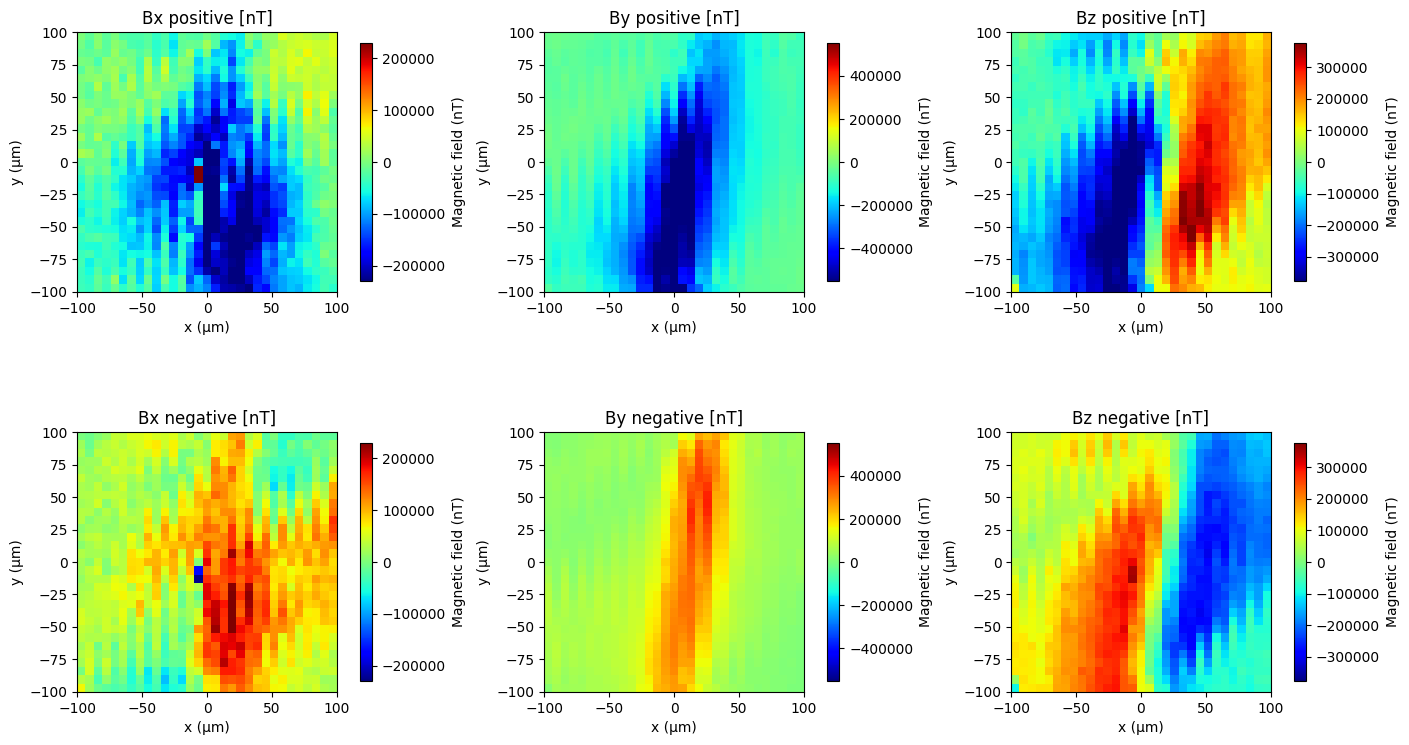

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)

maps = [
    ("Bx positive", Bx_pos_map, Bx_lim),
    ("By positive", By_pos_map, By_lim),
    ("Bz positive", Bz_pos_map, Bz_lim),
    ("Bx negative", Bx_neg_map, Bx_lim),
    ("By negative", By_neg_map, By_lim),
    ("Bz negative", Bz_neg_map, Bz_lim),
]

for ax, (title, data, lim) in zip(axes.ravel(), maps):
    if lim == 0:
        lim = 1.0

    im = ax.imshow(
        data,
        extent=extent_um,
        origin="lower",
        aspect="equal",
        cmap="jet",
        vmin=-lim,
        vmax=lim
    )
    ax.set_title(f"{title} [nT]")
    ax.set_xlabel("x (µm)")
    ax.set_ylabel("y (µm)")
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Magnetic field (nT)")

plt.show()

In [17]:
B_pos_mT = A_plus @ deltaNu_pos
B_neg_mT = A_plus @ deltaNu_neg

for name, arr in zip(
    ["Bx_pos", "By_pos", "Bz_pos", "Bx_neg", "By_neg", "Bz_neg"],
    [B_pos_mT[0], B_pos_mT[1], B_pos_mT[2], B_neg_mT[0], B_neg_mT[1], B_neg_mT[2]]
):
    vals = np.abs(arr).ravel()
    print(name,
          "| p50 [mT] =", np.nanpercentile(vals, 50),
          "| p95 [mT] =", np.nanpercentile(vals, 95),
          "| max [mT] =", np.nanmax(vals))

Bx_pos | p50 [mT] = 0.05594576904565216 | p95 [mT] = 0.23009875985560718 | max [mT] = 0.39910859092769313
By_pos | p50 [mT] = 0.11520971524180912 | p95 [mT] = 0.5543495442632362 | max [mT] = 0.6819554786792331
Bz_pos | p50 [mT] = 0.16392505755939424 | p95 [mT] = 0.37788921457892743 | max [mT] = 0.5803399639625502
Bx_neg | p50 [mT] = 0.05355712826723589 | p95 [mT] = 0.1665611794792615 | max [mT] = 0.2699081590885628
By_neg | p50 [mT] = 0.06409924711329228 | p95 [mT] = 0.3050200309583141 | max [mT] = 0.4158676153274853
Bz_neg | p50 [mT] = 0.14672443050131018 | p95 [mT] = 0.27573263008101667 | max [mT] = 0.3563774809751201
